Step 1: Environment Setup and Data Loading
In this cell, we install the necessary libraries (gensim for LDA and pyLDAvis for visualization). We then load the dataset, convert dates to a usable format, and clean the text to ensure we only process rows with actual content.

In [1]:
!pip install gensim pyLDAvis -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel

df = pd.read_parquet('/content/featured_news.parquet')
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')
df['year'] = df['date'].dt.year
df = df[df['clean_text'].notna() & (df['clean_text'] != '')].reset_index(drop=True)
print(f"Loaded: {df.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.2 MB/s eta 0:00:00
Loaded: (10000, 18)


### Step 2: Model A — TF-IDF Baseline
We start with a simple frequency-based approach (TF-IDF). This helps us see the most important words for specific months (like during the COVID outbreak). This serves as a 'baseline' to show that while we can find keywords, we can't yet group them into broader 'topics'.

In [2]:
# MODEL A — TF-IDF Baseline


def tfidf_top_keywords(df, period_str, top_k=10):
    mask = df['year_month'].astype(str) == period_str
    subset = df[mask]['clean_text']
    if len(subset) < 5:
        return []
    vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
    X = vec.fit_transform(subset)
    scores = np.asarray(X.mean(axis=0)).flatten()
    top_idx = scores.argsort()[-top_k:][::-1]
    return [(vec.get_feature_names_out()[i],
             round(float(scores[i]), 4)) for i in top_idx]

print("=" * 55)
print("MODEL A — TF-IDF BASELINE")
print("Limitation: no topic grouping, ignores semantics")
print("=" * 55)

test_months = {
    '2016-10': 'US Election buildup',
    '2020-03': 'COVID-19 outbreak',
    '2017-10': 'MeToo movement',
}
for month, event in test_months.items():
    kw = tfidf_top_keywords(df, month)
    if kw:
        print(f"\n{month} — {event}:")
        print(f"  Top keywords: {[k for k, v in kw[:8]]}")

print("\n→ Model A correctly surfaces event keywords")
print("→ BUT: cannot group them into coherent topics")
print("→ This is why we need LDA (Model B)")

MODEL A — TF-IDF BASELINE
Limitation: no topic grouping, ignores semantics

2020-03 — COVID-19 outbreak:
  Top keywords: ['the', 'to', 'and', 'of', 'coronavirus', 'in', 'for', 'is']

→ Model A correctly surfaces event keywords
→ BUT: cannot group them into coherent topics
→ This is why we need LDA (Model B)


### Step 3: Model B — LDA Hyperparameter Tuning
Latent Dirichlet Allocation (LDA) requires us to choose the number of topics (*k*). This cell iterates through different values of *k* and calculates 'Coherence' and 'Perplexity' scores to find the mathematical 'sweet spot' for our model.

Building gensim corpus...
Vocab before filter: 24912
Vocab after filter : 2620
Corpus: 10000 documents

Tuning k (num_topics) via coherence score...
Coherence c_v = PMI-based similarity of top words per topic

  k=10 | coherence=0.2908 | perplexity=-6.9371
  k=15 | coherence=0.3231 | perplexity=-7.0553
  k=20 | coherence=0.3114 | perplexity=-7.1326
  k=25 | coherence=0.2930 | perplexity=-7.1917
  k=30 | coherence=0.3085 | perplexity=-7.2388
  k=35 | coherence=0.3041 | perplexity=-7.2957
  k=40 | coherence=0.3006 | perplexity=-7.3442
  k=45 | coherence=0.3059 | perplexity=-7.3890
  k=50 | coherence=0.3138 | perplexity=-7.4443

→ Best k = 15 | coherence = 0.3231


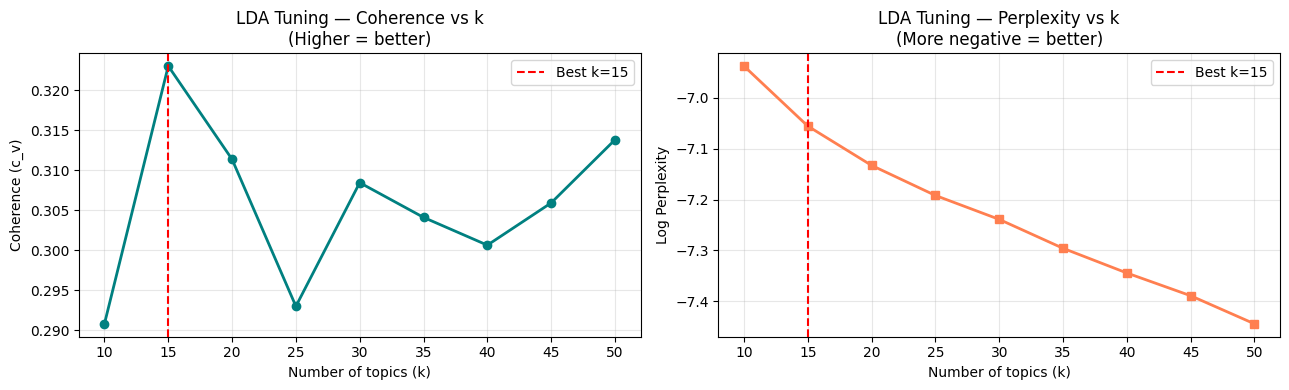

In [3]:
# MODEL B — LDA (Advanced ML)


print("Building gensim corpus...")
texts = [t.split() for t in df['clean_text'] if len(t.split()) >= 3]

dictionary = corpora.Dictionary(texts)
print(f"Vocab before filter: {len(dictionary)}")
dictionary.filter_extremes(no_below=15, no_above=0.5)
print(f"Vocab after filter : {len(dictionary)}")

corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Corpus: {len(corpus)} documents\n")

print("Tuning k (num_topics) via coherence score...")
print("Coherence c_v = PMI-based similarity of top words per topic\n")

topic_range = range(10, 55, 5)
coherence_scores = []
perplexity_scores = []

for k in topic_range:
    lda = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        alpha='auto',
        eta='auto'
    )
    cm = CoherenceModel(
        model=lda, texts=texts,
        dictionary=dictionary, coherence='c_v'
    )
    coh = cm.get_coherence()
    perp = lda.log_perplexity(corpus)
    coherence_scores.append(coh)
    perplexity_scores.append(perp)
    print(f"  k={k:2d} | coherence={coh:.4f} | perplexity={perp:.4f}")

best_k = list(topic_range)[np.argmax(coherence_scores)]
print(f"\n→ Best k = {best_k} | coherence = {max(coherence_scores):.4f}")

# Tuning plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(list(topic_range), coherence_scores,
         'o-', color='teal', linewidth=2, markersize=6)
ax1.axvline(best_k, color='red', linestyle='--',
            label=f'Best k={best_k}')
ax1.set_title('LDA Tuning — Coherence vs k\n(Higher = better)')
ax1.set_xlabel('Number of topics (k)')
ax1.set_ylabel('Coherence (c_v)')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(list(topic_range), perplexity_scores,
         's-', color='coral', linewidth=2, markersize=6)
ax2.axvline(best_k, color='red', linestyle='--',
            label=f'Best k={best_k}')
ax2.set_title('LDA Tuning — Perplexity vs k\n(More negative = better)')
ax2.set_xlabel('Number of topics (k)')
ax2.set_ylabel('Log Perplexity')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_lda_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 4: Training the Final LDA Model
Using the best *k* found in the previous step, we train the final model with more iterations (passes) to ensure stability. We then print out the top words for each discovered topic to interpret what they represent.

In [4]:
print(f"Training final LDA with k={best_k}, passes=15...")

lda_final = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto'
)

perplexity_final = lda_final.log_perplexity(corpus)
cm_final = CoherenceModel(
    model=lda_final, texts=texts,
    dictionary=dictionary, coherence='c_v'
)
coherence_final = cm_final.get_coherence()

print(f"\nFinal Perplexity : {perplexity_final:.4f}")
print(f"Final Coherence  : {coherence_final:.4f}")
print("\nDiscovered Topics:")
print("-" * 55)
for idx, topic in lda_final.print_topics(num_words=8):
    print(f"Topic {idx:2d}: {topic}")

Training final LDA with k=15, passes=15...

Final Perplexity : -7.0163
Final Coherence  : 0.3354

Discovered Topics:
-------------------------------------------------------
Topic  0: 0.052*"trump" + 0.023*"on" + 0.023*"donald" + 0.022*"a" + 0.022*"trumps" + 0.020*"news" + 0.019*"about" + 0.019*"of"
Topic  1: 0.037*"of" + 0.031*"for" + 0.026*"and" + 0.022*"at" + 0.020*"last" + 0.017*"with" + 0.016*"a" + 0.013*"year"
Topic  2: 0.055*"of" + 0.032*"in" + 0.023*"a" + 0.018*"women" + 0.016*"for" + 0.016*"and" + 0.015*"on" + 0.015*"accused"
Topic  3: 0.031*"and" + 0.030*"this" + 0.027*"of" + 0.027*"are" + 0.025*"from" + 0.020*"these" + 0.020*"a" + 0.017*"week"
Topic  4: 0.057*"he" + 0.036*"a" + 0.034*"his" + 0.029*"was" + 0.027*"said" + 0.024*"of" + 0.020*"says" + 0.017*"that"
Topic  5: 0.033*"for" + 0.033*"a" + 0.028*"gop" + 0.021*"democratic" + 0.020*"democrats" + 0.020*"in" + 0.019*"bill" + 0.018*"senate"
Topic  6: 0.045*"trump" + 0.022*"trumps" + 0.019*"in" + 0.017*"court" + 0.017*"is" + 

### Step 5: Analyzing Topic Trends Over Time
Here, we assign the most likely topic to every document in our database. We then plot the frequency of the top 5 topics over the years to see how public interest shifted (e.g., the rise of COVID-related topics in 2020).

Assigning dominant topics to documents...


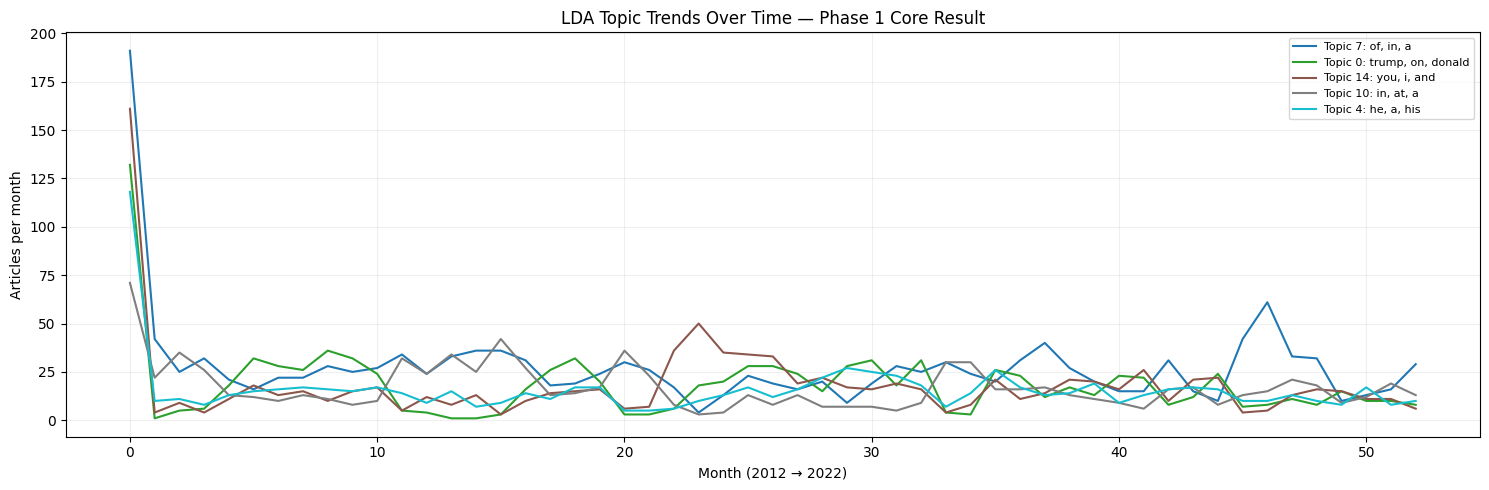

In [5]:
print("Assigning dominant topics to documents...")

df_lda = df[df['clean_text'].str.split().str.len() >= 3].copy().reset_index(drop=True)
corpus_full = [dictionary.doc2bow(t.split()) for t in df_lda['clean_text']]

def get_dominant_topic(bow):
    topics = lda_final.get_document_topics(bow, minimum_probability=0.0)
    return max(topics, key=lambda x: x[1])[0] if topics else -1

df_lda['dominant_topic'] = [get_dominant_topic(b) for b in corpus_full]
df_lda['year_month_str'] = df_lda['year_month'].astype(str)

# Plot top 5 topics over time
top_topics = df_lda['dominant_topic'].value_counts().head(5).index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, 5))

fig, ax = plt.subplots(figsize=(15, 5))
for i, t in enumerate(top_topics):
    series = df_lda[df_lda['dominant_topic'] == t].groupby('year_month_str').size()
    top_words = [w for w, _ in lda_final.show_topic(t, topn=3)]
    ax.plot(range(len(series)), series.values,
            label=f"Topic {t}: {', '.join(top_words)}",
            linewidth=1.5, color=colors[i])

ax.set_title('LDA Topic Trends Over Time — Phase 1 Core Result')
ax.set_xlabel('Month (2012 → 2022)')
ax.set_ylabel('Articles per month')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('08_topic_trends.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Phase 1 Ablation Table
Finally, we create a summary table comparing our different models. This documents the improvement from the simple TF-IDF baseline to the advanced LDA model and sets the stage for future hybrid models.

In [7]:
print("=" * 55)
print("ABLATION TABLE — Phase 1 (Required Deliverable)")
print("=" * 55)

ablation = pd.DataFrame([
    {
        'Model'      : 'Model A: TF-IDF Baseline',
        'Type'       : 'Frequency-based',
        'Coherence'  : 'N/A (qualitative)',
        'Perplexity' : 'N/A',
        'Notes'      : 'Top-K keywords per month'
    },
    {
        'Model'      : f'Model B: LDA (k={best_k})',
        'Type'       : 'Probabilistic (Adv ML)',
        'Coherence'  : f'{coherence_final:.4f}',
        'Perplexity' : f'{perplexity_final:.4f}',
        'Notes'      : 'EM tuned, α/η auto'
    },
    {
        'Model'      : 'Model C: Hybrid (Phase 3)',
        'Type'       : 'LDA + BERTopic + LSTM',
        'Coherence'  : 'TBD',
        'Perplexity' : 'TBD',
        'Notes'      : 'Phase 2-3 target'
    },
])

print(ablation.to_string(index=False))
ablation.to_csv('ablation_table.csv', index=False)

print(f"\nModel B improves over Model A:")
print(f"→ Model A: keywords only, no topic structure")
print(f"→ Model B: {best_k} coherent topics, probabilistic assignments")
print(f"→ Model C: Phase 3 (BERTopic + temporal evolution)")


ABLATION TABLE — Phase 1 (Required Deliverable)
                    Model                   Type         Coherence Perplexity                    Notes
 Model A: TF-IDF Baseline        Frequency-based N/A (qualitative)        N/A Top-K keywords per month
      Model B: LDA (k=15) Probabilistic (Adv ML)            0.3354    -7.0163       EM tuned, α/η auto
Model C: Hybrid (Phase 3)  LDA + BERTopic + LSTM               TBD        TBD         Phase 2-3 target

Model B improves over Model A:
→ Model A: keywords only, no topic structure
→ Model B: 15 coherent topics, probabilistic assignments
→ Model C: Phase 3 (BERTopic + temporal evolution)
